In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from config.setting import NUM_COLUMNS
from utils.helper import get_data_path
import math

# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

TARGET_COL = "price"  # target column name

df = pd.read_csv(get_data_path("final_data.csv"))

In [2]:
print(df.columns)

Index(['address', 'area', 'house_direction', 'balcony_direction', 'floors',
       'bedrooms', 'bathrooms', 'legal_status', 'furniture_state', 'price',
       'year', 'property_type', 'property_feature', 'lat', 'lng'],
      dtype='object')


In [3]:
print(df.shape)

(20356, 15)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20356 entries, 0 to 20355
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   address            20356 non-null  object 
 1   area               20356 non-null  float64
 2   house_direction    4718 non-null   object 
 3   balcony_direction  1239 non-null   object 
 4   floors             16050 non-null  float64
 5   bedrooms           19145 non-null  float64
 6   bathrooms          16025 non-null  float64
 7   legal_status       17422 non-null  object 
 8   furniture_state    10346 non-null  object 
 9   price              20356 non-null  float64
 10  year               20356 non-null  int64  
 11  property_type      20356 non-null  object 
 12  property_feature   20356 non-null  object 
 13  lat                20356 non-null  float64
 14  lng                20356 non-null  float64
dtypes: float64(7), int64(1), object(7)
memory usage: 2.3+ MB
None


In [5]:
print(df.isna().sum())

address                  0
area                     0
house_direction      15638
balcony_direction    19117
floors                4306
bedrooms              1211
bathrooms             4331
legal_status          2934
furniture_state      10010
price                    0
year                     0
property_type            0
property_feature         0
lat                      0
lng                      0
dtype: int64


In [6]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [7]:
df = df.drop_duplicates()


In [8]:
print(len(df))

20356


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

In [10]:
df = df[(df.price > df.price.quantile(0.01)) &
        (df.price < df.price.quantile(0.99))]

In [11]:
print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print(df[num_cols].describe().T)

Target column: price
Numerical columns: ['area', 'floors', 'bedrooms', 'bathrooms', 'price', 'year', 'lat', 'lng']
Categorical columns: ['address', 'house_direction', 'balcony_direction', 'legal_status', 'furniture_state', 'property_type', 'property_feature']
              count     mean    std      min      25%      50%      75%  \
area      19923.000   64.027 50.157    5.000   43.300   58.000   76.000   
floors    15726.000    2.932  1.578    1.000    2.000    3.000    4.000   
bedrooms  18729.000    3.426  1.488    1.000    2.000    3.000    4.000   
bathrooms 15681.000    3.272  1.461    1.000    2.000    3.000    4.000   
price     19923.000    6.513  2.464    1.850    4.700    6.280    8.000   
year      19923.000 2025.089  0.996 2024.000 2024.000 2026.000 2026.000   
lat       19923.000   10.799  0.049   10.403   10.764   10.798   10.836   
lng       19923.000  106.672  0.054  106.379  106.631  106.667  106.704   

               max  
area      4202.300  
floors      60.000  
b

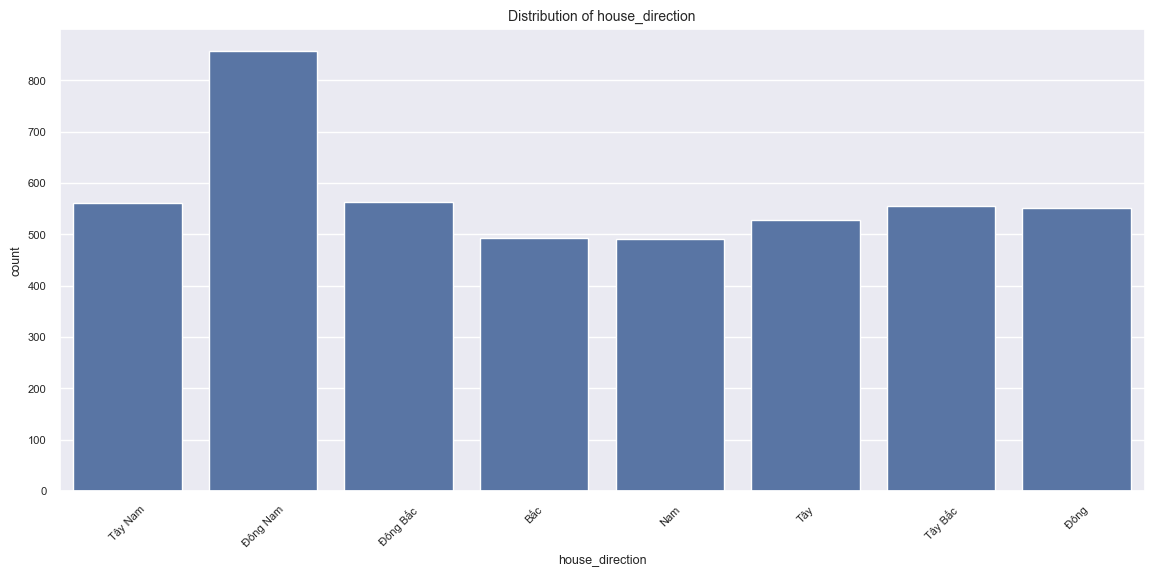

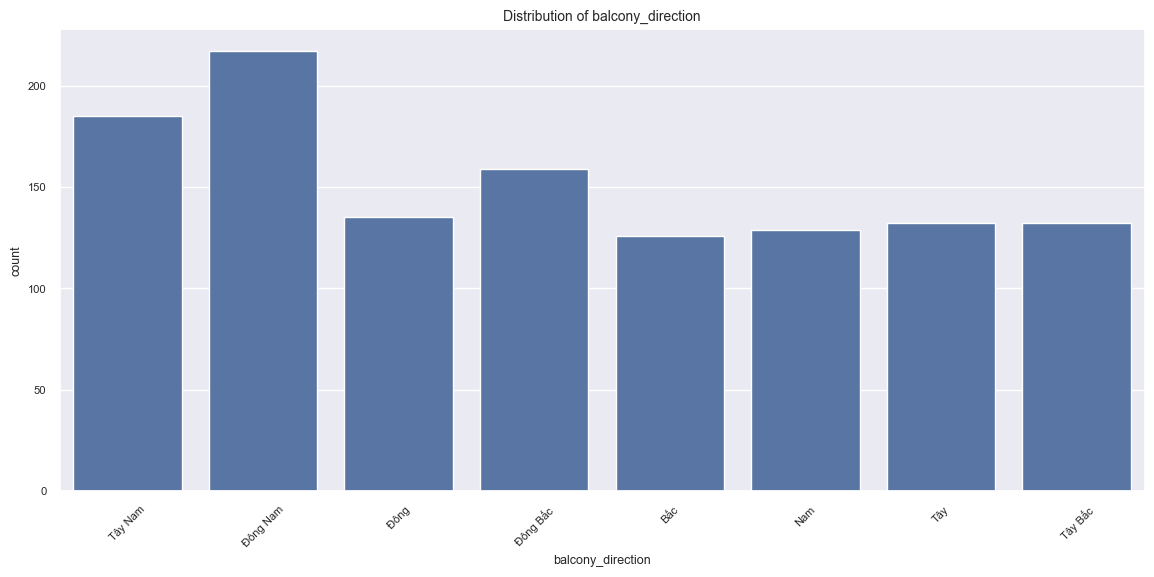

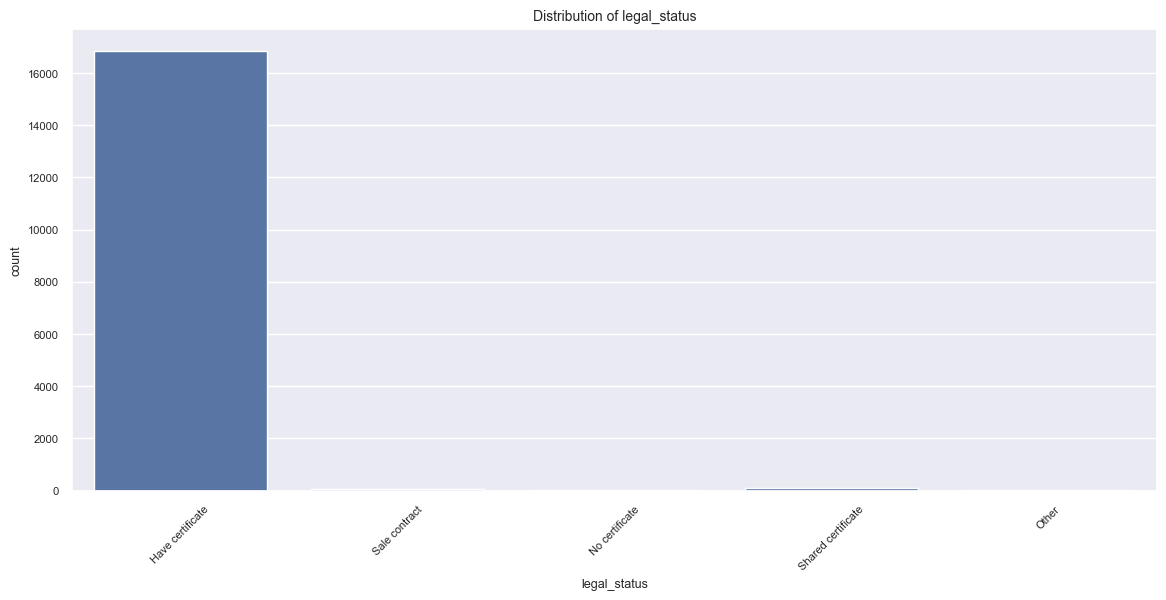

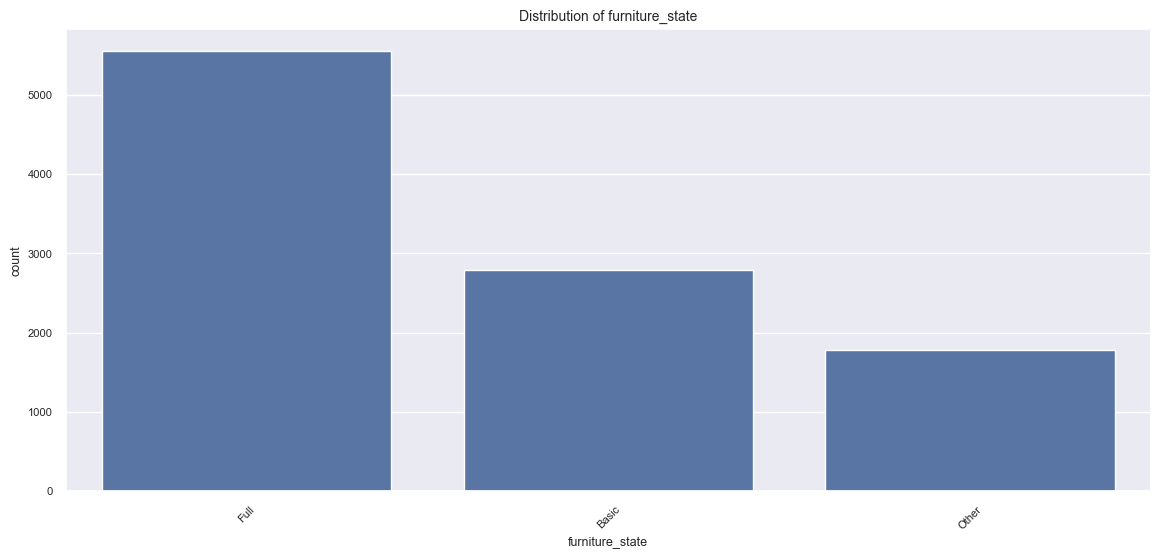

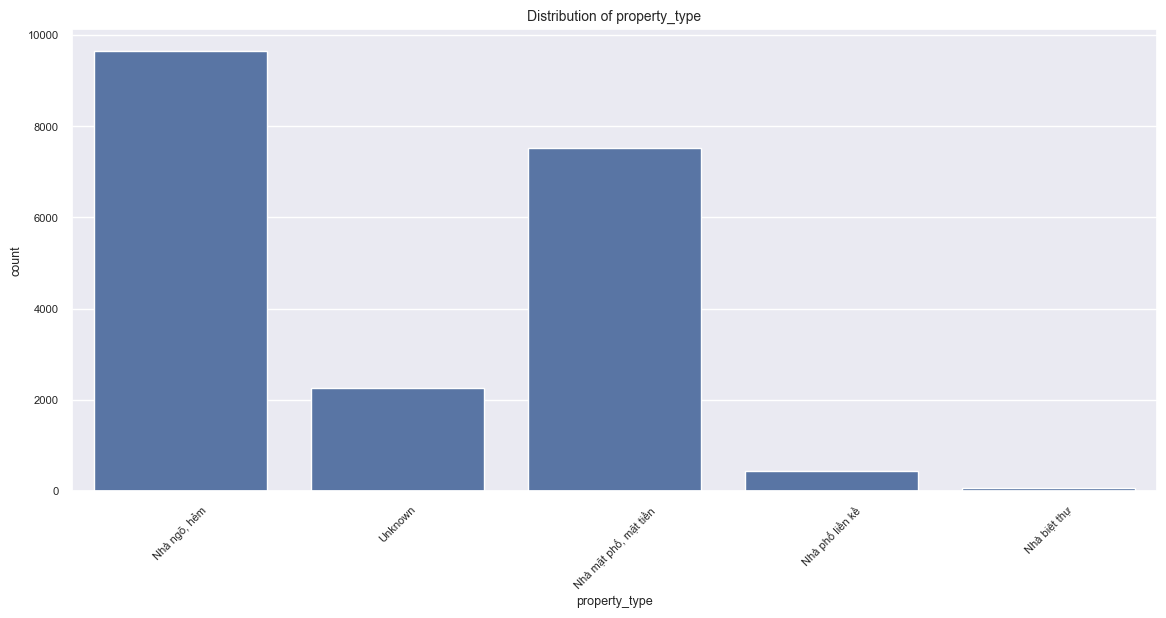

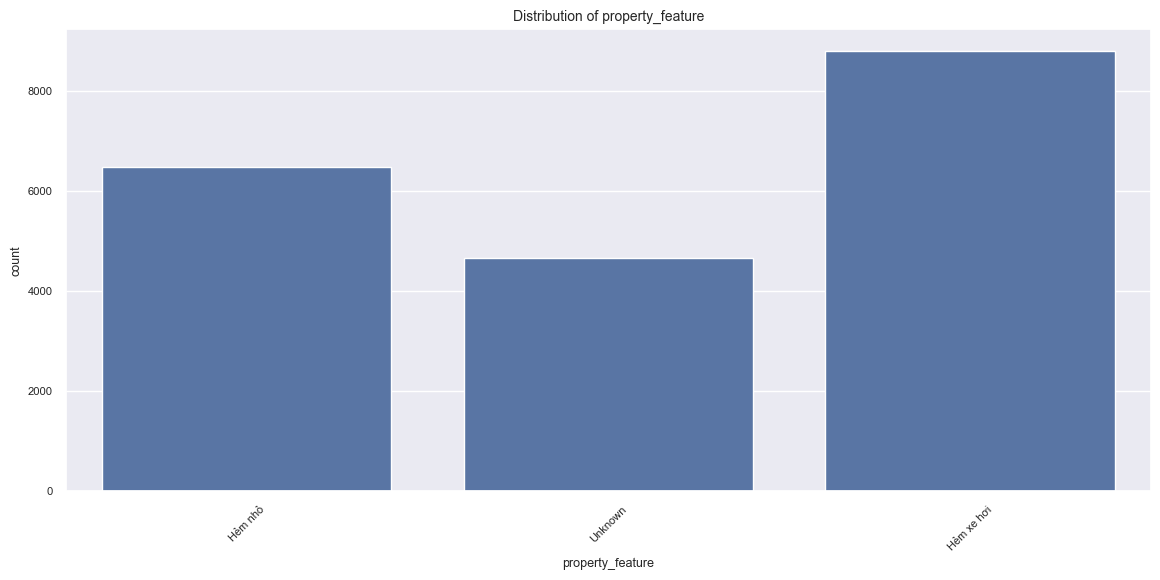

In [12]:
safe_cat_cols = [c for c in cat_cols if df[c].nunique() < 50]
for col in safe_cat_cols:
    plt.figure(figsize=(14, 6))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

df = df[(df.price > df.price.quantile(0.01)) &
        (df.price < df.price.quantile(0.99))]

area
Top 5 max values:
12575   4202.300
15188   1568.000
9957    1300.000
19388    828.600
16577    628.000
Name: area, dtype: float64

floors
Top 5 max values:
12098   60.000
9928    50.000
17631   44.000
9590    44.000
9864    43.000
Name: floors, dtype: float64

bedrooms
Top 5 max values:
19309   11.000
14885   11.000
15053   11.000
19520   11.000
9408    11.000
Name: bedrooms, dtype: float64

bathrooms
Top 5 max values:
7485   9.000
6427   9.000
6112   9.000
6116   9.000
6035   9.000
Name: bathrooms, dtype: float64

price
Top 5 max values:
18970   13.750
18769   13.750
19533   13.700
19550   13.680
19150   13.600
Name: price, dtype: float64

year
Top 5 max values:
20355    2026
20352    2026
20351    2026
20349    2026
20348    2026
Name: year, dtype: int64

lat
Top 5 max values:
18997   11.388
13987   11.253
10056   11.183
13468   11.119
13600   11.105
Name: lat, dtype: float64

lng
Top 5 max values:
18236   107.040
19142   106.923
13097   106.923
9653    106.863
10692   106.861
N

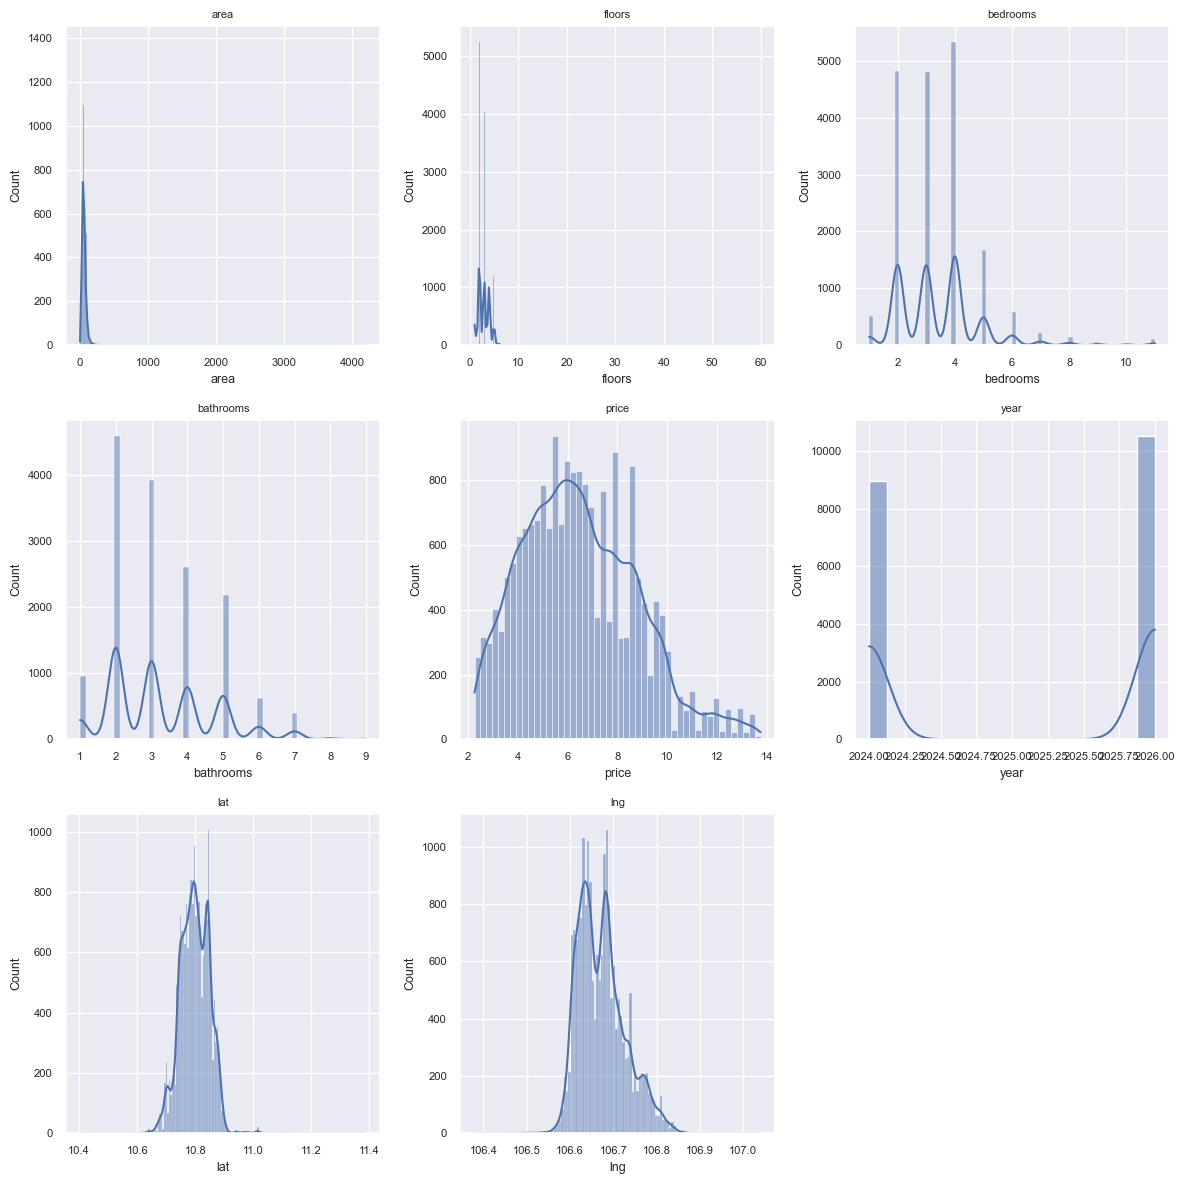

In [13]:

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
for col in num_cols:
    print(col)
    print("Top 5 max values:")
    print(df[col].sort_values(ascending=False).head())
    print()
# Ẩn subplot dư
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [14]:
df = df[df["area"] < df["area"].quantile(0.99)]
df["area"].sort_values(ascending=False).head()

13600   178.500
12001   178.000
7264    178.000
804     177.000
2576    177.000
Name: area, dtype: float64

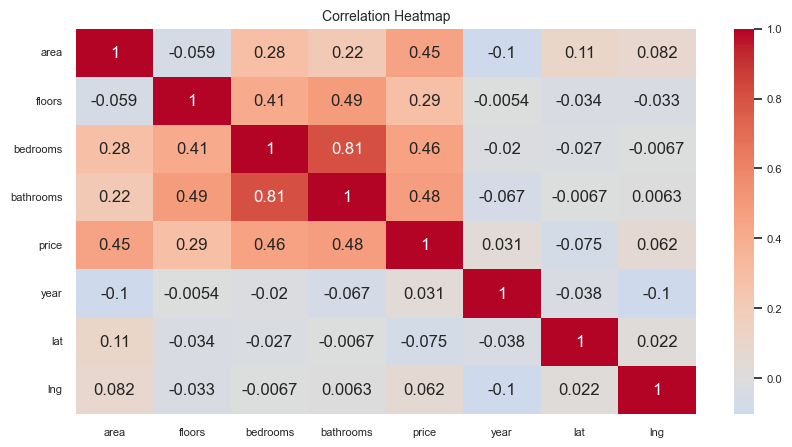


Correlation with target:
price        1.000
bathrooms    0.482
bedrooms     0.457
area         0.446
floors       0.285
lng          0.062
year         0.031
lat         -0.075
Name: price, dtype: float64


In [15]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


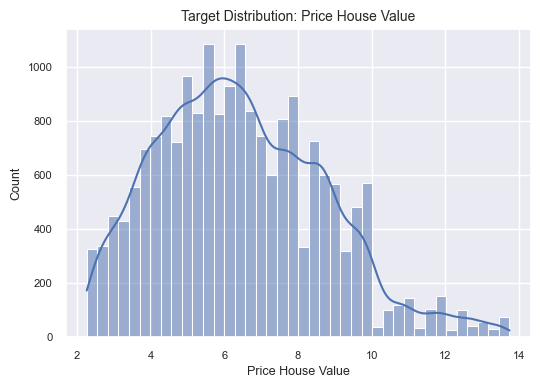

price
6.500     475
8.500     406
7.500     385
5.500     359
6.000     327
         ... 
4.530       1
13.380      1
12.122      1
3.240       1
13.050      1
Name: count, Length: 712, dtype: int64


In [16]:
# target column distribution

plt.figure(figsize=(6, 4))
sns.histplot(df['price'], bins=40, kde=True)
plt.title("Target Distribution: Price House Value")

plt.xlabel("Price House Value")
plt.show()
print(df['price'].value_counts())


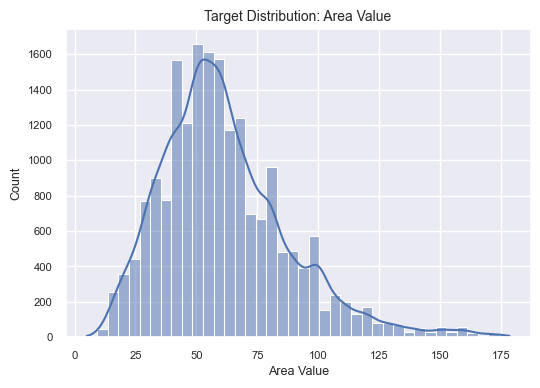

area
60.000     1053
40.000      716
50.000      632
80.000      630
56.000      537
           ... 
109.200       1
74.400        1
105.400       1
67.160        1
19.840        1
Name: count, Length: 1049, dtype: int64


In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(df['area'], bins=40, kde=True)
plt.title("Target Distribution: Area Value")

plt.xlabel("Area Value")
plt.show()
print(df['area'].value_counts())


In [18]:
print("Floors > 15:", (df["floors"] > 15).sum())
print("Floors is NaN:", df["floors"].isna().sum())

Floors > 15: 18
Floors is NaN: 3984


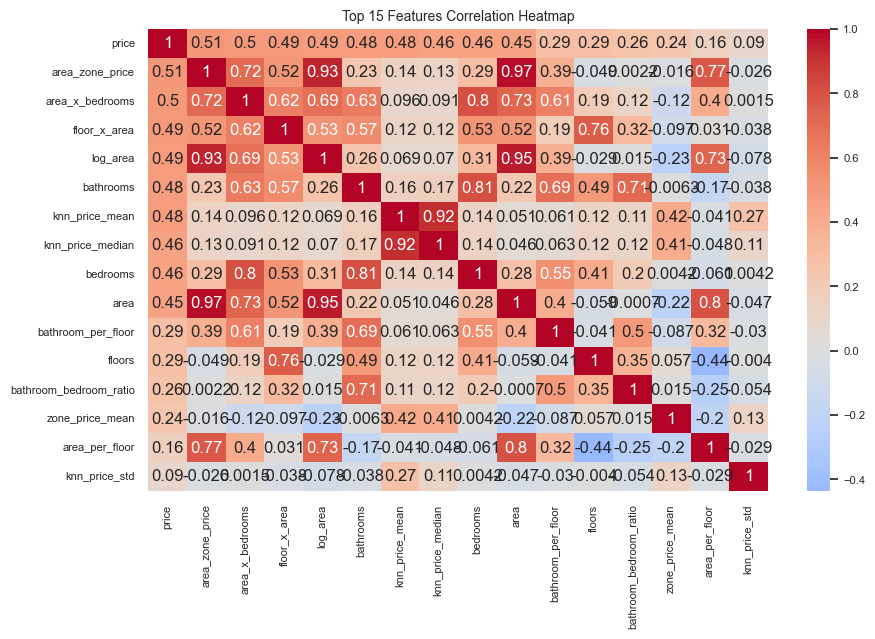


Top 15 features correlated with target:
price                    1.000
area_zone_price          0.508
area_x_bedrooms          0.499
floor_x_area             0.495
log_area                 0.485
bathrooms                0.482
knn_price_mean           0.480
knn_price_median         0.460
bedrooms                 0.457
area                     0.446
bathroom_per_floor       0.290
floors                   0.285
bathroom_bedroom_ratio   0.263
zone_price_mean          0.237
area_per_floor           0.158
knn_price_std            0.090


In [19]:
from features.feature_engineering import build_features

df = build_features(df, mode="train")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)

top15_features = corr_with_target.drop(TARGET_COL).head(15).index.tolist()

cols_for_heatmap = [TARGET_COL] + top15_features

# ===== Heatmap =====
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[cols_for_heatmap].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Top 15 Features Correlation Heatmap")
plt.show()

# ===== In ra correlation =====
print("\nTop 15 features correlated with target:")
print(corr_with_target.head(16).to_string())  # 16 vì có cả target
